In [699]:
import sys
import os

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.append(project_root)


import importlib
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import DQN
import matplotlib.pyplot as plt
import torch

# Import as module
import environment.users.citation_users_loader as citation_users_loader
importlib.reload(citation_users_loader)

import environment.citations.citation_selector as citation_selector
importlib.reload(citation_selector)

import environment.citation_reward_shaping as citation_reward_shaping
importlib.reload(citation_reward_shaping)

import environment.citations.citation as citation
importlib.reload(citation)

import environment.users.citation_user as citation_user
importlib.reload(citation_user)

import environment.citation_memory as citation_memory
importlib.reload(citation_memory)

import environment.users.user_rater as user_rater
importlib.reload(user_rater)

import environment.user_env as user_env
importlib.reload(user_env)

from environment.user_env import UserEnv
from environment.users.citation_users_loader import CitationUsersLoader
from environment.citations.citation_loader import CitationsLoader
from environment.citations.citation import Citation
from environment.citations.citation_selector import CitationsSelector
from environment.citation_memory import CitationMemory
from environment.users.citation_user import CitationUser
from environment.users.user_rater import RuleBasedCitationRater
from environment.citation_reward_shaping import CitationRewardReshapingExpDecay
# from environment.items_retrieval import ItemsRetrieval
# from environment.items_selection import ItemsSelector

### Testing CitationUsersLoader class

In [700]:
users_loader = CitationUsersLoader("../../environment/users/datasets/users_with_popular_interests.json")
user_list = users_loader.get_users()
print(user_list[0])
print(user_list[1])
print(user_list[2])

### Tesing CitationLoader class

In [701]:
paper_path = "../../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv"
paper_loader = CitationsLoader(paper_path)
paper_ids = paper_loader.load_all_ids()
papers = paper_loader.load_items()
print(f"Loaded {len(paper_ids)} papers.")

In [702]:
print(papers[0])

### Test CitationSelector class

In [703]:
selector = CitationsSelector()
selected_papers = selector.select(papers[0:5], [0.1, 0.5, 0.7, 0.4, 0.9])

In [704]:
selected_papers

([<environment.citations.citation.Citation at 0x34cf0c430>,
 [0, 0, 0.7, 0, 0.9])

### Test CitationMemory class

In [705]:
memory = CitationMemory(paper_loader)
print(f"Users to show paper: {memory.user_to_shown_papers}")
memory.update_memory(user_id=user_list[0].id, items_ids=[papers[0].id], scores=[0.7])
print(f"Users to show paper: {memory.user_to_shown_papers}")
memory.update_memory(user_id=user_list[1].id, items_ids=[papers[3].id, papers[4].id], scores=[0.4, 0.8])
print(f"Users to show paper: {memory.user_to_shown_papers}")

In [706]:
list_items_ids, list_interactions = memory.get_items_and_scores(user_id=1)
print([paper.id for paper in list_items_ids])
print([user_paper.rating for user_paper in list_interactions])

In [707]:
memory.update_memory(user_id=user_list[1].id, items_ids=[papers[3].id], scores=[0.3])
print(f"Users to show paper: {memory.user_to_shown_papers}")

In [708]:
list_items_ids, list_interactions = memory.get_items_and_scores(user_id=1)
print([paper.id for paper in list_items_ids])
print([user_paper.rating for user_paper in list_interactions])

### Test UserRater class

In [709]:
rater = RuleBasedCitationRater()

In [710]:
user = user_list[1]
print(user)

In [711]:
paper = papers[20]
print(paper)

In [712]:
print(rater.compute_semantic_topic_score(user=user, item=paper))
print(rater.compute_reputability_score(reputability_bias=user.reputability_bias, item=paper))
print(rater.compute_novelty_score(novelty_bias=user.novelty_bias, item=paper))
print(rater.rate(user=user, item=paper))

### Test UserEnv

In [713]:
env = UserEnv(
    render_mode= "human",
    items_loader=paper_loader,
    users_loader=users_loader,
    items_selector=citation_selector,
    reward_shaping=CitationRewardReshapingExpDecay(),
    render_path="./tmp/render/",
)
env = Monitor(env)

In [714]:
model = DQN("MultiInputPolicy", env, verbose=1, 
            device="cpu",
            exploration_fraction=0.7, 
            learning_starts=1000,
            buffer_size=50000,
            batch_size=64,
            target_update_interval=500,
            exploration_final_eps=0.2)
model.learn(total_timesteps=10000)

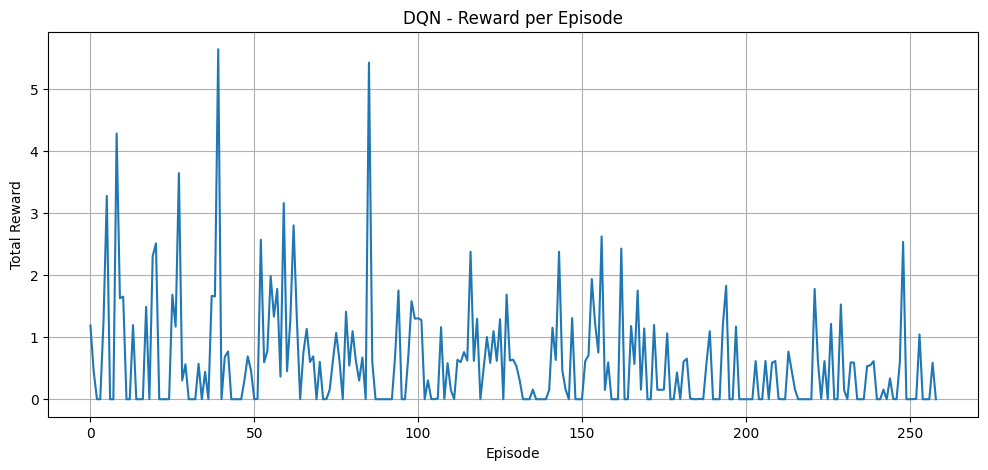

In [715]:
rewards = env.get_episode_rewards()
plt.figure(figsize=(12, 5))
plt.plot(rewards)
plt.title("DQN - Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

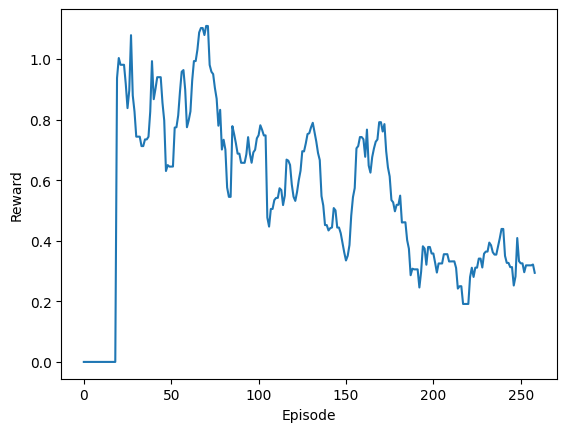

In [716]:
def plot_rewards(episode_rewards, window_size=20):
    rewards_t = torch.tensor(episode_rewards, dtype=torch.float)
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    if len(rewards_t) >= window_size:
        means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(window_size-1), means))
        plt.plot(means.numpy())

plot_rewards(rewards)

In [717]:
env.user_list

[User(id = 0, interests=['Complex Network Analysis Techniques', 'Academic Publishing and Open Access', 'Expert finding and Q&A systems'], relevance_threshold=0.7, reputability_bias=0.25, novelty_bias=0.66),
 User(id = 1, interests=['Academic Publishing and Open Access', 'Psychology Research and Bibliometrics'], relevance_threshold=0.5, reputability_bias=0.93, novelty_bias=0.7),
 User(id = 2, interests=['Academic Writing and Publishing', 'Academic Publishing and Open Access'], relevance_threshold=0.6, reputability_bias=0.4, novelty_bias=0.33)]